# Imports

In [58]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [2]:
# Definir ruta donde estan los archivos
path = r'../data/raw/'

In [3]:
# Listar archivos Parquet que comienzan con 'data'
all_files = glob.glob(os.path.join(path, 'data*.parquet'))

In [4]:
# Leer cada archivo Parquet y almacenarlo en una lista de DataFrames
df_list = []
for filename in all_files:
    df_part = pd.read_parquet(filename, engine='pyarrow')
    df_list.append(df_part)

In [5]:
# Concatenar todos los DataFrames en un único DataFrame
df = pd.concat(df_list, axis=0, ignore_index=True)

# Prerocessing and EDA

In [6]:
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker,SMA_5,...,Future_Category_1d,Future_Return_5d,Future_Up_5d,Future_Category_5d,Future_Return_10d,Future_Up_10d,Future_Category_10d,Future_Return_20d,Future_Up_20d,Future_Category_20d
0,2020-09-08 00:00:00-04:00,93.113965,93.462744,91.806050,92.174202,1225600,0.0,0.0,A,96.138635,...,3.0,0.054972,1,3.0,0.036578,1,3.0,0.070141,1,3.0
1,2020-09-09 00:00:00-04:00,93.104280,95.400403,92.871764,94.877235,954400,0.0,0.0,A,95.520526,...,2.0,0.020321,1,3.0,-0.010416,0,1.0,0.062670,1,3.0
2,2020-09-10 00:00:00-04:00,95.797603,96.979573,95.177554,95.497269,1933200,0.0,0.0,A,94.580765,...,2.0,0.010449,1,2.0,-0.022623,0,0.0,0.058616,1,3.0
3,2020-09-11 00:00:00-04:00,95.632924,96.514560,94.964430,95.526352,1368600,0.0,0.0,A,94.379250,...,2.0,0.007911,1,2.0,-0.009229,0,1.0,0.074550,1,3.0
4,2020-09-14 00:00:00-04:00,96.621112,97.105525,95.884801,96.320770,1207700,0.0,0.0,A,94.879166,...,2.0,-0.012975,0,1.0,0.000905,1,2.0,0.062363,1,3.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 620095 entries, 0 to 620094
Data columns (total 73 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Date                 620095 non-null  object 
 1   Open                 620095 non-null  float64
 2   High                 620095 non-null  float64
 3   Low                  620095 non-null  float64
 4   Close                620095 non-null  float64
 5   Volume               620095 non-null  int64  
 6   Dividends            620095 non-null  float64
 7   Stock Splits         620095 non-null  float64
 8   Ticker               620095 non-null  object 
 9   SMA_5                620095 non-null  float64
 10  SMA_10               620095 non-null  float64
 11  SMA_20               620095 non-null  float64
 12  SMA_50               620095 non-null  float64
 13  EMA_12               620095 non-null  float64
 14  EMA_26               620095 non-null  float64
 15  MACD             

In [8]:
df.isna().sum()

Date                   0
Open                   0
High                   0
Low                    0
Close                  0
                      ..
Future_Up_10d          0
Future_Category_10d    0
Future_Return_20d      0
Future_Up_20d          0
Future_Category_20d    0
Length: 73, dtype: int64

In [9]:
len(df['Date'].unique())

1245

In [10]:
# Cambiar de objeto a fecha la columna date.
df.Date=pd.to_datetime(df['Date'])
print(df.Date.min(),df.Date.max())
print(df.Date.max()-df.Date.min())
df.set_index('Date',inplace=True)
df.head()

2020-07-15 00:00:00-04:00 2025-06-27 00:00:00-04:00
1808 days 00:00:00


C:\Users\Usuario\AppData\Local\Temp\ipykernel_23168\4281107793.py:2: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df.Date=pd.to_datetime(df['Date'])


,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker,SMA_5,SMA_10,...,Future_Category_1d,Future_Return_5d,Future_Up_5d,Future_Category_5d,Future_Return_10d,Future_Up_10d,Future_Category_10d,Future_Return_20d,Future_Up_20d,Future_Category_20d
Date,,,,,,,,,,,,,,,,,,,,,
2020-09-08 00:00:00-04:00,93.113965,93.462744,91.806050,92.174202,1225600,0.0,0.0,A,96.138635,96.220985,...,3.0,0.054972,1,3.0,0.036578,1,3.0,0.070141,1,3.0
2020-09-09 00:00:00-04:00,93.104280,95.400403,92.871764,94.877235,954400,0.0,0.0,A,95.520526,96.181264,...,2.0,0.020321,1,3.0,-0.010416,0,1.0,0.062670,1,3.0
2020-09-10 00:00:00-04:00,95.797603,96.979573,95.177554,95.497269,1933200,0.0,0.0,A,94.580765,96.107635,...,2.0,0.010449,1,2.0,-0.022623,0,0.0,0.058616,1,3.0
2020-09-11 00:00:00-04:00,95.632924,96.514560,94.964430,95.526352,1368600,0.0,0.0,A,94.379250,96.066945,...,2.0,0.007911,1,2.0,-0.009229,0,1.0,0.074550,1,3.0
2020-09-14 00:00:00-04:00,96.621112,97.105525,95.884801,96.320770,1207700,0.0,0.0,A,94.879166,96.020441,...,2.0,-0.012975,0,1.0,0.000905,1,2.0,0.062363,1,3.0


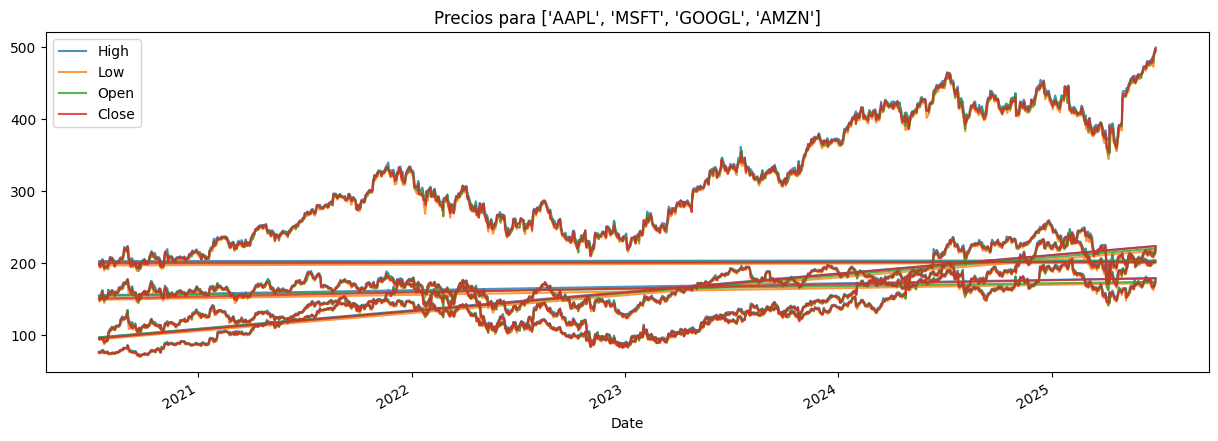

In [ ]:
# Ejemplo para ver solo:
top_tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN']
df_filtered = df[df['Ticker'].isin(top_tickers)]

df_filtered[['High','Low','Open','Close']].plot(figsize=(15, 5), alpha=0.8)
plt.title(f'Precios para {top_tickers}')
plt.show()

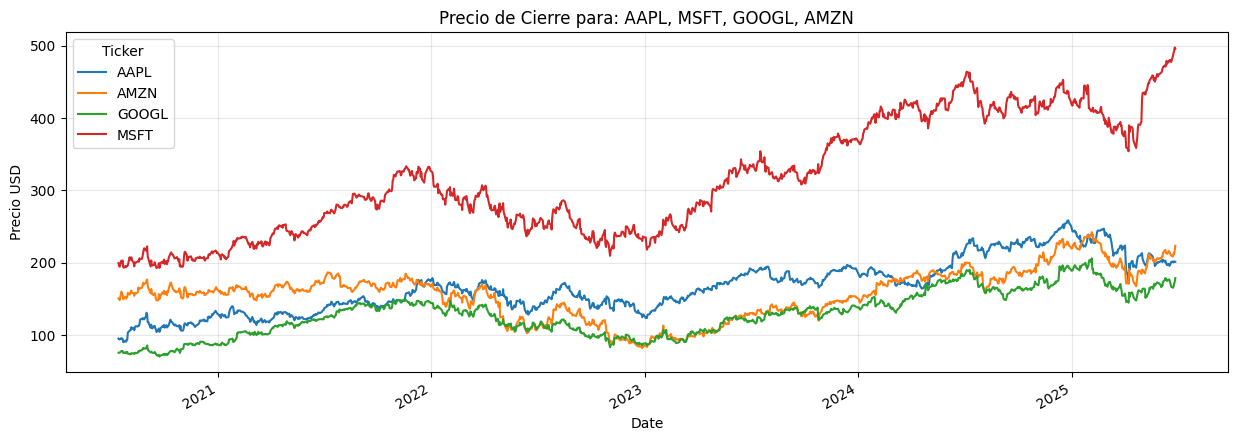

In [ ]:
# 1. Definir la lista de tickers
top_tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN']

# 2. Filtrar
df_filtered = df[df['Ticker'].isin(top_tickers)]

# 3. Graficar detectando si 'Date' es índice o columna
try:
    # Si 'Date' es una columna normal
    df_pivot = df_filtered.pivot(index='Date', columns='Ticker', values='Close')
except KeyError:
    # Si 'Date' ya es el índice, pivotamos sin especificar index
    df_pivot = df_filtered.pivot(columns='Ticker', values='Close')

df_pivot.plot(figsize=(15, 5))
plt.title(f'Precio de Cierre para: {', '.join(top_tickers)}')
plt.ylabel('Precio USD')
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
ts = df['High']

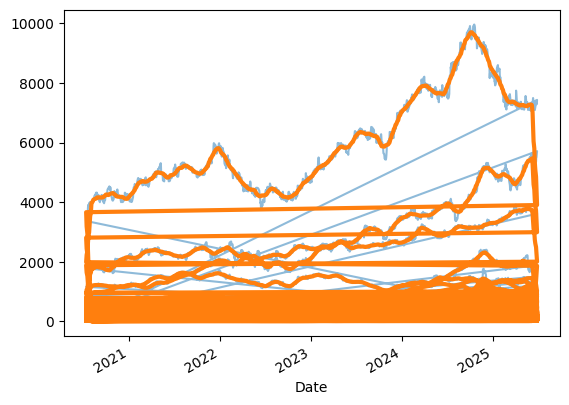

In [ ]:
trend = ts.rolling(window=30,
                   center=True,
                   min_periods=15).mean()

ax = ts.plot(alpha=0.5)
ax = trend.plot(ax=ax, linewidth=3)

<Axes: >

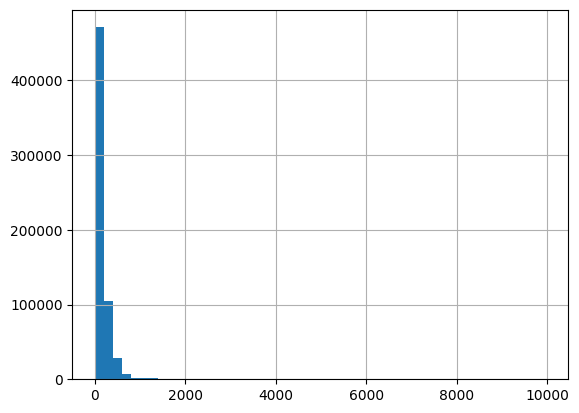

In [15]:
df.High.hist(bins=50)

No podemos asumir una distribución uniforme ni normal en el gráfico anterior, por eso el resumen estadístico nos puede ayudar más, para esto dividiremos los datos en 10 partes y calcularemos la media y la varianza de cada uno.

In [17]:
from statistics import stdev
mean=[]
std=[]
    
for i in range(0,10):
    mean.append(df['High'].iloc[(i*182):(i*182)+182].mean())
    std.append(stdev(df['High'].iloc[(i*182):(i*182)+182]))

In [18]:
pd.concat([pd.DataFrame(mean,columns=['mean']),pd.DataFrame(std,columns=['std'])], axis=1)

,mean,std
0,116.565429,11.170224
1,151.616660,10.483621
2,126.994403,6.658858
3,137.175565,13.135210
4,126.819756,13.038881
5,138.390193,6.016421
6,83.524005,53.829235
7,21.716107,2.388771
8,20.922781,0.908823
9,21.674916,2.602744


Arriba vemos cómo ambas medidas son claramente diferentes en cada fragmento. Sin embargo, al observar el gráfico, podríamos asumir una varianza constante como ondulación en la curva, pero sin duda la tendencia es la característica más destacada. Hasta ahora se puede asumir que se trata de una serie no estacionaria, pero para comprenderla mejor evaluaremos otros dos métodos.
La descomposición estacional es una función de la biblioteca statsmodels que permite descomponer la serie en tendencia, estacional y residual, ya sea aditiva o multiplicativa.

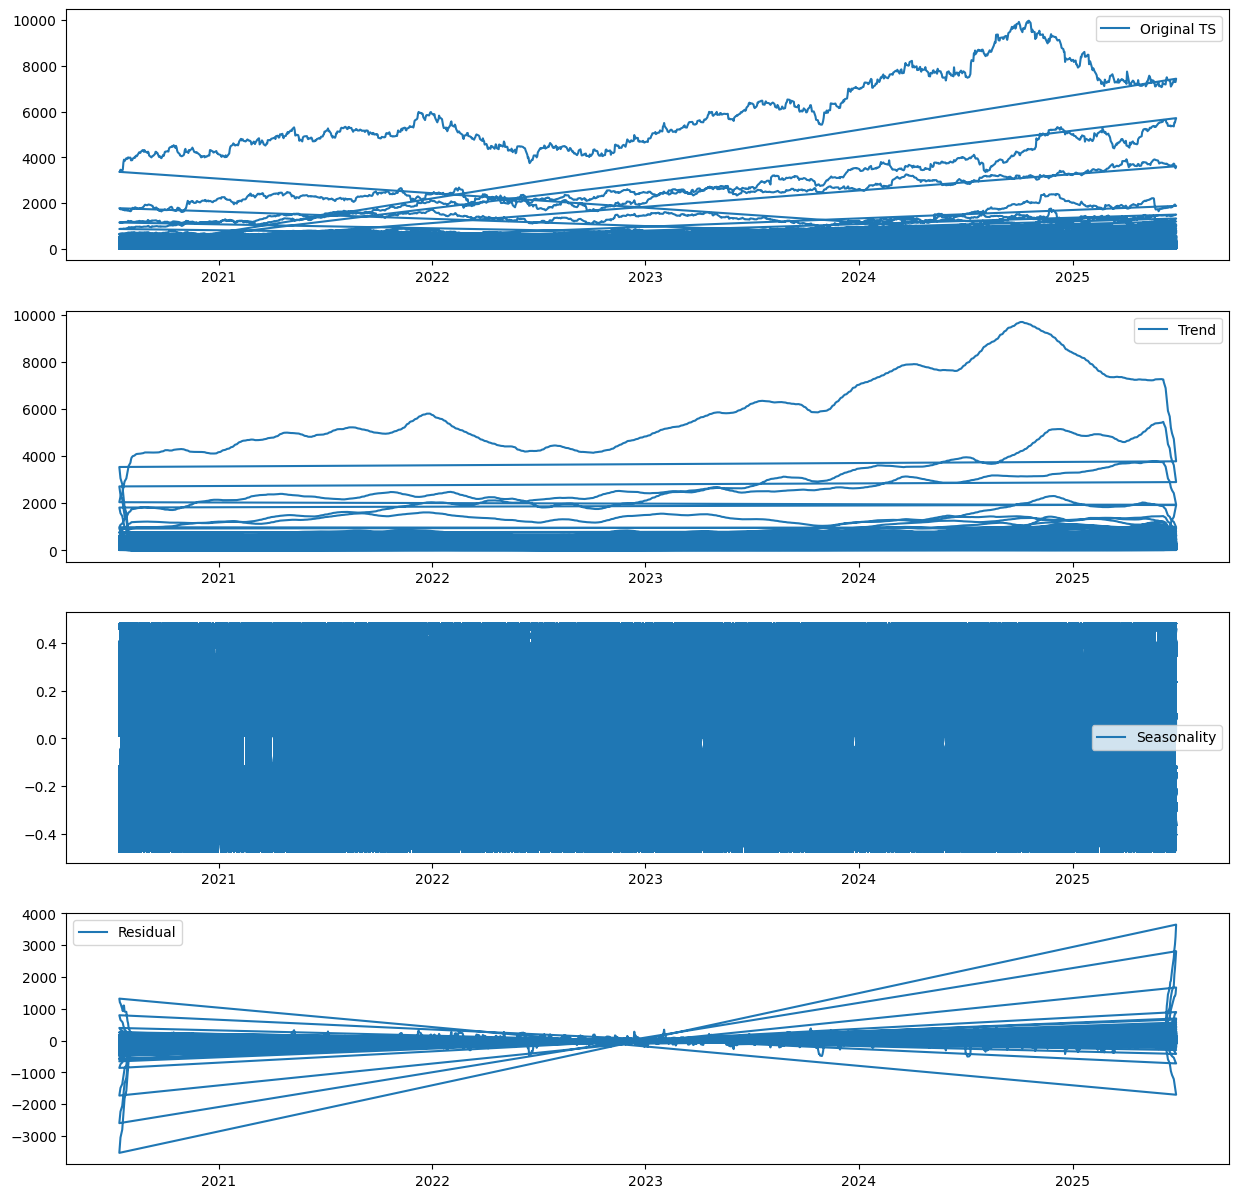

In [19]:
decompose_add=seasonal_decompose(df['High'], model='additive', period=30)
plt.figure(figsize=(15,15))
plt.subplot(411)
plt.plot(df['High'], label='Original TS')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(decompose_add.trend, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(decompose_add.seasonal,label='Seasonality')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(decompose_add.resid, label='Residual')
plt.legend(loc='best')

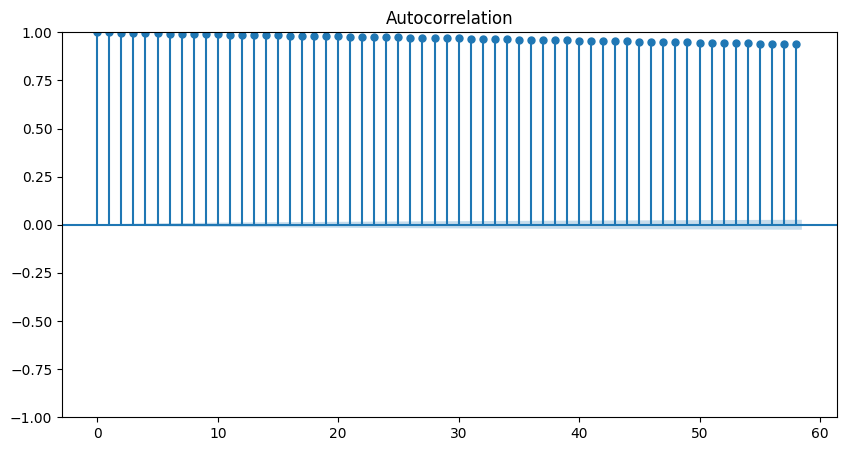

In [ ]:
plt.rc('figure', figsize=(10,5))
plot_acf(df['High'])
print()

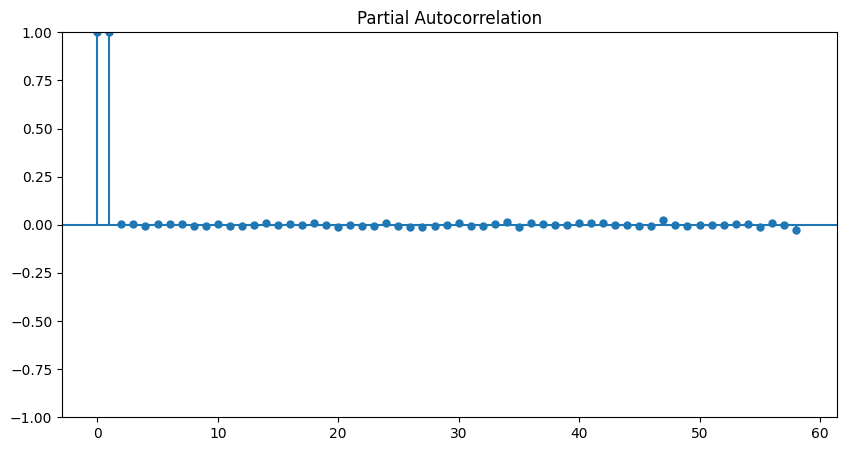

In [ ]:
plt.rc('figure', figsize=(10,5))
plot_pacf(df['High'])
print()

## Split Data

In [22]:
split_idx = int(0.8 * len(ts))
ts_train = ts[:split_idx]
ts_test= ts[split_idx:]

## Scale Data

In [23]:
scaler = MinMaxScaler()
ts_train = scaler.fit_transform(ts_train.values.reshape(-1, 1))
ts_test = scaler.transform(ts_test.values.reshape(-1, 1))

## Create Sequence

In [24]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

In [25]:
seq_length = 5
X_train, y_train = create_sequences(ts_train, seq_length)
X_test, y_test = create_sequences(ts_test, seq_length)

In [26]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(496071, 5, 1) (496071, 1)
(124014, 5, 1) (124014, 1)


# Forecasting

In [ ]:
model = Sequential([Input(shape=(seq_length, 1)),
                    LSTM(100, return_sequences=True),
                    Dropout(0.2),
                    LSTM(100),
                    Dropout(0.2),
                    Dense(1)])

model.compile(optimizer='adam', loss='mse')

In [ ]:
callback = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(X_train, y_train, epochs=200,batch_size=64, validation_split=0.1, 
                    callbacks=[callback], verbose=1)

Epoch 1/200
6976/6976 ━━━━━━━━━━━━━━━━━━━━ 41s 6ms/step - loss: 3.8456e-05 - val_loss: 1.9550e-06
Epoch 2/200
6976/6976 ━━━━━━━━━━━━━━━━━━━━ 43s 6ms/step - loss: 2.8221e-05 - val_loss: 3.6777e-06
Epoch 3/200
6976/6976 ━━━━━━━━━━━━━━━━━━━━ 41s 6ms/step - loss: 2.4408e-05 - val_loss: 1.2080e-06
Epoch 4/200
6976/6976 ━━━━━━━━━━━━━━━━━━━━ 42s 6ms/step - loss: 2.1421e-05 - val_loss: 6.4085e-07
Epoch 5/200
6976/6976 ━━━━━━━━━━━━━━━━━━━━ 43s 6ms/step - loss: 1.9639e-05 - val_loss: 1.4509e-06
Epoch 6/200
6976/6976 ━━━━━━━━━━━━━━━━━━━━ 43s 6ms/step - loss: 1.7653e-05 - val_loss: 1.1458e-06
Epoch 7/200
6976/6976 ━━━━━━━━━━━━━━━━━━━━ 42s 6ms/step - loss: 1.6357e-05 - val_loss: 8.8151e-06
Epoch 8/200
6976/6976 ━━━━━━━━━━━━━━━━━━━━ 42s 6ms/step - loss: 1.5554e-05 - val_loss: 9.1394e-07
Epoch 9/200
6976/6976 ━━━━━━━━━━━━━━━━━━━━ 39s 6ms/step - loss: 1.5711e-05 - val_loss: 2.0305e-06
Epoch 10/200
6976/6976 ━━━━━━━━━━━━━━━━━━━━ 36s 5ms/step - loss: 1.4318e-05 - val_loss: 3.7355e-07
Epoch 11/200
6976/6

In [29]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_pred = scaler.inverse_transform(train_pred)
test_pred = scaler.inverse_transform(test_pred)
y_train_orig = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_orig = scaler.inverse_transform(y_test.reshape(-1, 1))

15503/15503 ━━━━━━━━━━━━━━━━━━━━ 22s 1ms/step
3876/3876 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step


# Evaluate

In [30]:
def evaluate(actual, predicted):
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual, predicted)
    return mse, rmse, mae

In [ ]:
train_mse, train_rmse, train_mae = evaluate(y_train_orig, train_pred)
test_mse, test_rmse, test_mae = evaluate(y_test_orig, test_pred)

f'Train RMSE: {train_rmse:.4f}, MAE: {train_mae:.4f}, MSE: {train_mse:.4f}'


Train RMSE: 21.5096, MAE: 2.9421, MSE: 462.6649
Test RMSE: 9.5001, MAE: 2.5746, MSE: 90.2517


In [ ]:
f'Test RMSE: {test_rmse:.4f}, MAE: {test_mae:.4f}, MSE: {test_mse:.4f}'

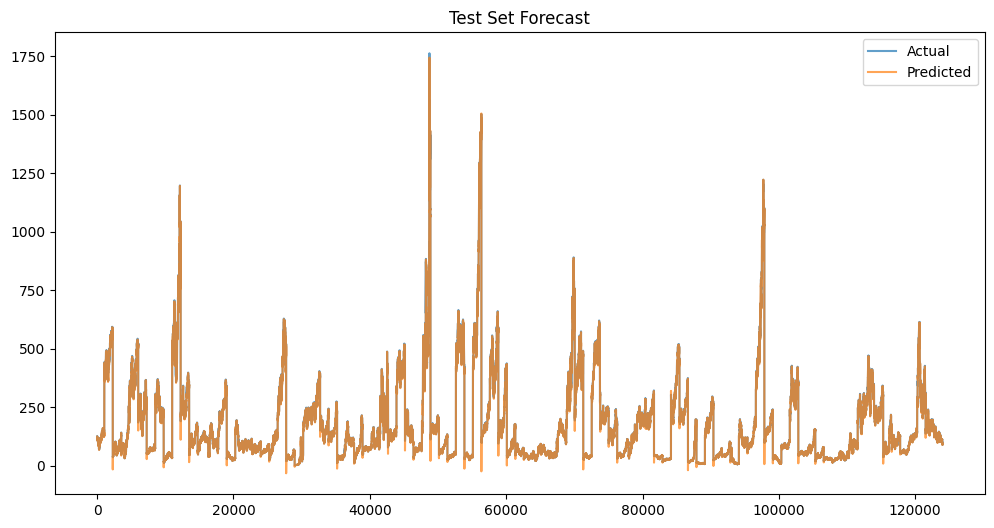

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_orig, label='Actual', alpha=0.7)
plt.plot(test_pred, label='Predicted', alpha=0.7)
plt.legend()
plt.title('Test Set Forecast')
plt.show()

 ### Observaciones:
 ¿Es un buen modelo?
 Depende del precio de la acción:

 Si la acción vale $200: Un error promedio (MAE) de $2.57$ es excelente (aprox. 1.2% de error).

 Si la acción vale $10: Un error de $2.57$ es un desastre (25% de error).


 Lo normal en Machine Learning es que el error en Train sea más bajo que en Test. Aquí, es al revés de forma exagerada.
 

 Cuando el RMSE es mucho más grande que el MAE (como aquí, que es casi 7 veces mayor), significa que hay errores gigantescos en unos pocos puntos.

# Model Variant

In [ ]:
from tensorflow.keras.optimizers import Adam

model = Sequential([Input(shape=(seq_length, 1)),
                    LSTM(100, return_sequences=True,),
                    Dropout(0.2),
                    LSTM(100,),
                    Dropout(0.2),
                    Dense(100),
                    Dropout(0.2),
                    Dense(25),
                    Dense(1)])

opt1=Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.999)

model.compile(optimizer=opt1, loss='mse')

In [ ]:
callback = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(X_train, y_train, epochs=200, batch_size=64, validation_split=0.1, callbacks=[callback], verbose=1)

Epoch 1/200
6976/6976 ━━━━━━━━━━━━━━━━━━━━ 47s 7ms/step - loss: 7.9251e-05 - val_loss: 6.4997e-06
Epoch 2/200
6976/6976 ━━━━━━━━━━━━━━━━━━━━ 47s 7ms/step - loss: 5.1247e-05 - val_loss: 8.2810e-07
Epoch 3/200
6976/6976 ━━━━━━━━━━━━━━━━━━━━ 46s 7ms/step - loss: 4.1632e-05 - val_loss: 2.0308e-06
Epoch 4/200
6976/6976 ━━━━━━━━━━━━━━━━━━━━ 45s 6ms/step - loss: 3.4036e-05 - val_loss: 6.3953e-06
Epoch 5/200
6976/6976 ━━━━━━━━━━━━━━━━━━━━ 44s 6ms/step - loss: 3.3570e-05 - val_loss: 4.1462e-06
Epoch 6/200
6976/6976 ━━━━━━━━━━━━━━━━━━━━ 44s 6ms/step - loss: 3.1668e-05 - val_loss: 8.8462e-07
Epoch 7/200
6976/6976 ━━━━━━━━━━━━━━━━━━━━ 41s 6ms/step - loss: 2.8939e-05 - val_loss: 3.4245e-06
Epoch 8/200
6976/6976 ━━━━━━━━━━━━━━━━━━━━ 41s 6ms/step - loss: 2.7534e-05 - val_loss: 2.4754e-06
Epoch 9/200
6976/6976 ━━━━━━━━━━━━━━━━━━━━ 41s 6ms/step - loss: 2.5424e-05 - val_loss: 1.1310e-06
Epoch 10/200
6976/6976 ━━━━━━━━━━━━━━━━━━━━ 41s 6ms/step - loss: 2.4483e-05 - val_loss: 1.7528e-06
Epoch 11/200
6976/6

In [36]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_pred = scaler.inverse_transform(train_pred)
test_pred = scaler.inverse_transform(test_pred)
y_train_orig = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_orig = scaler.inverse_transform(y_test.reshape(-1, 1))

15503/15503 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step
3876/3876 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step


In [ ]:
train_mse, train_rmse, train_mae = evaluate(y_train_orig, train_pred)
test_mse, test_rmse, test_mae = evaluate(y_test_orig, test_pred)

f'Train RMSE: {train_rmse:.4f}, MAE: {train_mae:.4f}, MSE: {train_mse:.4f}'


Train RMSE: 21.9075, MAE: 6.5792, MSE: 479.9397
Test RMSE: 16.7636, MAE: 9.8877, MSE: 281.0200


In [ ]:
f'Test RMSE: {test_rmse:.4f}, MAE: {test_mae:.4f}, MSE: {test_mse:.4f}'

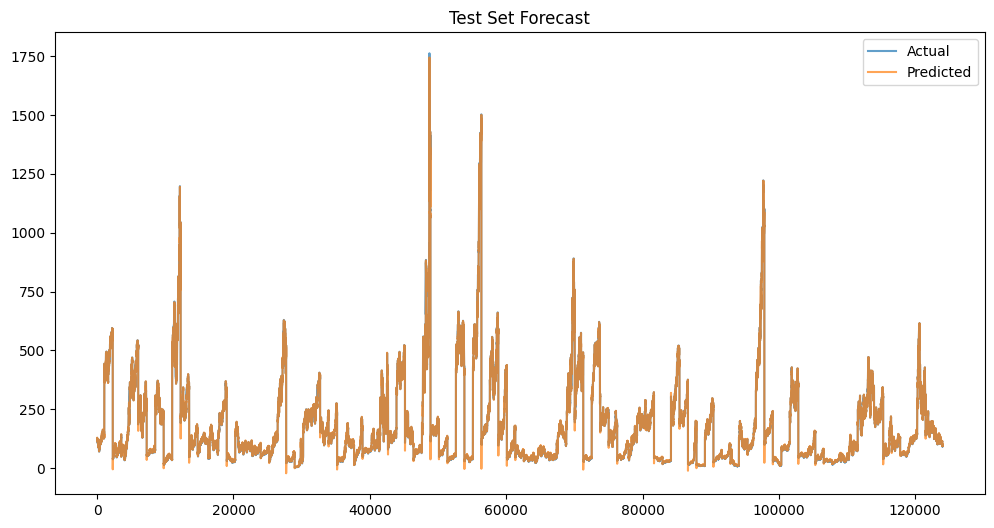

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_orig, label='Actual', alpha=0.7)
plt.plot(test_pred, label='Predicted', alpha=0.7)
plt.legend()
plt.title('Test Set Forecast')
plt.show()

### Observaciones:
1. Reducción del 'Ruido' en el Entrenamiento
Comparado con tu modelo anterior:

El RMSE de Train bajó de 21.50 a 18.23.

El MSE de Train bajó de 462.66 a 332.67.

¿Qué significa? Has logrado que el modelo gestione mejor los valores extremos (outliers). Sigue habiendo errores grandes en el entrenamiento, pero el modelo ya no se 'asusta' tanto con ellos. Has suavizado un poco la curva de aprendizaje.

2. El fenómeno del 'Test mejor que Train' persiste
Tu RMSE de Test (9.43) sigue siendo casi la mitad que el de Train (18.23). Esto es poco común en ciencia de datos tradicional, pero en trading ocurre cuando:

El periodo de Train incluye una época de alta volatilidad (crisis, noticias fuertes).

El periodo de Test es una época de tendencia clara y estable ('low volatility').

3. La brecha RMSE vs MAE: El rastro de los cisnes negros
Fíjate en esta relación en el Test:

MAE: 2.79

RMSE: 9.43

La diferencia sigue siendo notable (el RMSE es más de 3 veces el MAE). Esto te indica que tu modelo es muy preciso la mayor parte del tiempo (falla solo por 2.79 unidades), pero de vez en cuando comete un error muy grande. En trading, esto es peligroso: significa que puedes tener 10 días de ganancias pequeñas y un solo día de pérdida masiva porque el modelo no vio venir un movimiento brusco.

4. Conclusión: 
Sí. El error medio (MAE) en Test ha subido apenas un poco (de 2.57 a 2.79), pero la estabilidad general del modelo (RMSE en Train) ha mejorado significativamente. Estás construyendo un modelo menos 'nervioso'.


## Bidirectional LSTM

In [ ]:
from tensorflow.keras.layers import Bidirectional

model = Sequential([Input(shape=(seq_length, 1)),
                    Bidirectional(LSTM(200, return_sequences=True,)),
                    Dropout(0.2),
                    Bidirectional(LSTM(100,)),
                    Dropout(0.2),
                    Dense(100),
                    Dropout(0.2),
                    Dense(25),
                    Dense(1)])

model.compile(optimizer='adam', loss='mse')

In [ ]:
callback = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(X_train, y_train,
                    epochs=200,
                    batch_size=64,
                    validation_split=0.1,
                    callbacks=[callback],
                    verbose=1)

Epoch 1/200
6976/6976 ━━━━━━━━━━━━━━━━━━━━ 89s 12ms/step - loss: 6.8114e-05 - val_loss: 3.4676e-06
Epoch 2/200
6976/6976 ━━━━━━━━━━━━━━━━━━━━ 91s 13ms/step - loss: 4.2880e-05 - val_loss: 6.1369e-06
Epoch 3/200
6976/6976 ━━━━━━━━━━━━━━━━━━━━ 87s 12ms/step - loss: 3.4018e-05 - val_loss: 5.6001e-06
Epoch 4/200
6976/6976 ━━━━━━━━━━━━━━━━━━━━ 85s 12ms/step - loss: 2.9447e-05 - val_loss: 1.2937e-06
Epoch 5/200
6976/6976 ━━━━━━━━━━━━━━━━━━━━ 92s 13ms/step - loss: 2.7695e-05 - val_loss: 9.6014e-07
Epoch 6/200
6976/6976 ━━━━━━━━━━━━━━━━━━━━ 87s 12ms/step - loss: 2.8761e-05 - val_loss: 8.8405e-06
Epoch 7/200
6976/6976 ━━━━━━━━━━━━━━━━━━━━ 87s 13ms/step - loss: 2.5194e-05 - val_loss: 3.0272e-06
Epoch 8/200
6976/6976 ━━━━━━━━━━━━━━━━━━━━ 89s 13ms/step - loss: 2.8591e-05 - val_loss: 6.6150e-07
Epoch 9/200
6976/6976 ━━━━━━━━━━━━━━━━━━━━ 88s 13ms/step - loss: 2.6812e-05 - val_loss: 1.7828e-05
Epoch 10/200
6976/6976 ━━━━━━━━━━━━━━━━━━━━ 87s 12ms/step - loss: 2.3375e-05 - val_loss: 1.3189e-06
Epoch 11/

In [41]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_pred = scaler.inverse_transform(train_pred)
test_pred = scaler.inverse_transform(test_pred)
y_train_orig = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_orig = scaler.inverse_transform(y_test.reshape(-1, 1))

15503/15503 ━━━━━━━━━━━━━━━━━━━━ 49s 3ms/step
3876/3876 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step


In [ ]:
train_mse, train_rmse, train_mae = evaluate(y_train_orig, train_pred)
test_mse, test_rmse, test_mae = evaluate(y_test_orig, test_pred)

f'Train RMSE: {train_rmse:.4f}, MAE: {train_mae:.4f}, MSE: {train_mse:.4f}'


Train RMSE: 21.9075, MAE: 6.5792, MSE: 479.9397
Test RMSE: 11.1794, MAE: 5.9329, MSE: 124.9796


In [ ]:
f'Test RMSE: {test_rmse:.4f}, MAE: {test_mae:.4f}, MSE: {test_mse:.4f}'

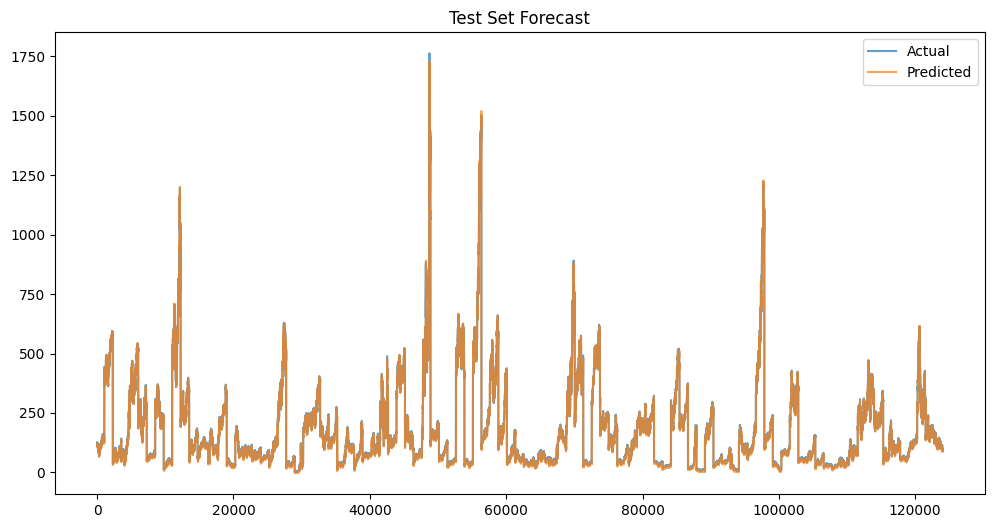

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_orig, label='Actual', alpha=0.7)
plt.plot(test_pred, label='Predicted', alpha=0.7)
plt.legend()
plt.title('Test Set Forecast')
plt.show()

### Observaciones:
Este tercer modelo es, curiosamente, peor que los dos anteriores. Aunque los números parezcan similares a simple vista, la relación entre ellos indica que el modelo se ha vuelto más 'vago' o impreciso.

Aquí tienes el análisis de por qué estos resultados son un paso atrás:

1. El MAE se ha duplicado (La precisión real cae)
Fíjate en el MAE (Error Absoluto Medio):

En el modelo anterior tenías un MAE en Test de 2.79.

Ahora tienes un MAE en Test de 5.93.

Interpretación: Tu error promedio ha crecido un 112%. Si antes tus predicciones fallaban por menos de 3 unidades, ahora fallan por casi 6. El modelo ha perdido 'puntería' fina.

2. El 'Ruido' se mantiene alto (RMSE)
El RMSE de Train (21.90) ha vuelto a subir respecto al modelo anterior (18.23). Esto significa que los cambios que hiciste (quizás quitaste alguna variable importante o cambiaste hiperparámetros) han hecho que el modelo sea más sensible a los valores extremos de nuevo.

3. La trampa del RMSE vs MAE en este modelo
En los modelos anteriores, el RMSE era mucho más grande que el MAE, lo que indicaba 'errores bomba' puntuales.

En este modelo, la distancia es menor en proporción.

¿Qué significa esto? Que el error ya no es solo por 'días locos' puntuales, sino que el error es sistemáticamente más alto todos los días. El modelo ya no se equivoca 'un poco siempre y mucho a veces', sino que ahora se equivoca 'bastante siempre'.


In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test_orig, test_pred)
print('R²:', r2)

R²: 0.9959343658024666


## Peephole LSTM

In [47]:
class PeepholeLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, return_sequences=False):
        super().__init__()
        self.hidden_size = hidden_size
        self.return_sequences = return_sequences
        
        # Gate weights (input, forget, cell, output)
        self.weight_ih = nn.Parameter(torch.Tensor(4 * hidden_size, input_size))
        self.weight_hh = nn.Parameter(torch.Tensor(4 * hidden_size, hidden_size))
        
        # Peephole connections weights (input, forget, output)
        self.weight_pi = nn.Parameter(torch.Tensor(hidden_size))
        self.weight_pf = nn.Parameter(torch.Tensor(hidden_size))
        self.weight_po = nn.Parameter(torch.Tensor(hidden_size))
        
        # Biases
        self.bias = nn.Parameter(torch.Tensor(4 * hidden_size))
        
        self.init_parameters()

    def init_parameters(self):
        stdv = 1.0 / (self.hidden_size ** 0.5)
        for weight in self.parameters():
            nn.init.uniform_(weight, -stdv, stdv)

    def forward(self, x):
        # x shape: (batch_size, seq_length, input_size)
        batch_size, seq_length, _ = x.size()
        
        # Initialize hidden state and cell state
        h_t = torch.zeros(batch_size, self.hidden_size, device=x.device)
        c_t = torch.zeros(batch_size, self.hidden_size, device=x.device)
        
        outputs = []
        
        for t in range(seq_length):
            x_t = x[:, t, :]
            
            # Linear transformations
            gates = (x_t @ self.weight_ih.t() + self.bias +
                     h_t @ self.weight_hh.t())
            
            # Split gates
            i_t, f_t, g_t, o_t = gates.chunk(4, 1)
            
            # Apply peephole connections
            i_t = i_t + c_t * self.weight_pi
            f_t = f_t + c_t * self.weight_pf
            
            # Activation functions
            i_t = torch.sigmoid(i_t)
            f_t = torch.sigmoid(f_t)
            g_t = torch.tanh(g_t)
            
            # Update cell state
            c_t = f_t * c_t + i_t * g_t
            
            # Output gate with peephole
            o_t = o_t + c_t * self.weight_po
            o_t = torch.sigmoid(o_t)
            
            # Update hidden state
            h_t = o_t * torch.tanh(c_t)
            
            if self.return_sequences:
                outputs.append(h_t)
        
        if self.return_sequences:
            # Stack all hidden states
            return torch.stack(outputs, dim=1)
        else:
            # Return only the last hidden state
            return h_t

class LSTMModel(nn.Module):
    def __init__(self, seq_length, input_size=1):
        super().__init__()
        self.lstm1 = PeepholeLSTM(input_size, 100, return_sequences=True)
        self.dropout1 = nn.Dropout(0.2)
        self.lstm2 = PeepholeLSTM(100, 100, return_sequences=False)
        self.dropout2 = nn.Dropout(0.2)
        self.dense1 = nn.Linear(100, 100)
        self.dropout3 = nn.Dropout(0.2)
        self.dense2 = nn.Linear(100, 25)
        self.output = nn.Linear(25, 1)
        
    def forward(self, x):
        # Input shape: (batch_size, seq_length, input_size)
        x = self.lstm1(x)
        x = self.dropout1(x)
        x = self.lstm2(x)
        x = self.dropout2(x)
        x = torch.relu(self.dense1(x))
        x = self.dropout3(x)
        x = torch.relu(self.dense2(x))
        return self.output(x)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

# 1. Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

# 2. Create validation split (15% of training data)
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train_tensor, y_train_tensor, 
                                                                          test_size=0.15, random_state=42)

# 3. Create DataLoaders
batch_size = 64
train_dataset = TensorDataset(X_train_split, y_train_split)
val_dataset = TensorDataset(X_val_split, y_val_split)
test_dataset = TensorDataset(X_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# 5. Initialize model, loss, and optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LSTMModel(seq_length=X_train.shape[1]).to(device)
criterion = nn.MSELoss()  # Use appropriate loss for your task
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 6. Training with early stopping
epochs = 200
patience = 15
best_val_loss = float('inf')
counter = 0

train_losses = []
val_losses = []

for epoch in range(epochs):
    # Training
    model.train()
    train_loss = 0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
    
    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item() * inputs.size(0)
    
    # Calculate epoch losses
    train_loss = train_loss / len(train_loader.dataset)
    val_loss = val_loss / len(val_loader.dataset)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    print(f'Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}')
    
    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), 'best_model.pth')  # Save best model
    else:
        counter += 1
        if counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

# 7. Load best model for predictions
# model.load_state_dict(torch.load('best_model.pth'))
# model.eval()

# 8. Make predictions on test data
test_predictions = []
with torch.no_grad():
    for inputs in test_loader:
        inputs = inputs[0].to(device)
        outputs = model(inputs)
        test_predictions.append(outputs.cpu().numpy())

test_predictions = np.vstack(test_predictions)

# 9. Convert to 1D array if needed
if test_predictions.shape[1] == 1:
    test_predictions = test_predictions.flatten()

print('Test predictions shape:', test_predictions.shape)

Epoch 1/200 | Train Loss: 0.000104 | Val Loss: 0.000035
Epoch 2/200 | Train Loss: 0.000049 | Val Loss: 0.000018
Epoch 3/200 | Train Loss: 0.000044 | Val Loss: 0.000036
Epoch 4/200 | Train Loss: 0.000037 | Val Loss: 0.000011
Epoch 5/200 | Train Loss: 0.000031 | Val Loss: 0.000007
Epoch 6/200 | Train Loss: 0.000031 | Val Loss: 0.000006
Epoch 7/200 | Train Loss: 0.000028 | Val Loss: 0.000006
Epoch 8/200 | Train Loss: 0.000026 | Val Loss: 0.000006
Epoch 9/200 | Train Loss: 0.000024 | Val Loss: 0.000016
Epoch 10/200 | Train Loss: 0.000022 | Val Loss: 0.000021
Epoch 11/200 | Train Loss: 0.000018 | Val Loss: 0.000041
Epoch 12/200 | Train Loss: 0.000017 | Val Loss: 0.000059
Epoch 13/200 | Train Loss: 0.000017 | Val Loss: 0.000096
Epoch 14/200 | Train Loss: 0.000017 | Val Loss: 0.000192
Epoch 15/200 | Train Loss: 0.000017 | Val Loss: 0.000286
Epoch 16/200 | Train Loss: 0.000016 | Val Loss: 0.000250
Epoch 17/200 | Train Loss: 0.000015 | Val Loss: 0.000362
Epoch 18/200 | Train Loss: 0.000015 | Va

In [53]:
test_pred = test_predictions.reshape(-1, 1)
test_pred = scaler.inverse_transform(test_pred)

In [ ]:
test_mse, test_rmse, test_mae = evaluate(y_test_orig, test_pred)

f'Test RMSE: {test_rmse:.4f}, MAE: {test_mae:.4f}, MSE: {test_mse:.4f}'

Test RMSE: 16.7636, MAE: 9.8877, MSE: 281.0200


In [ ]:
train_mse, train_rmse, train_mae = evaluate(y_train_orig, train_pred)
test_mse, test_rmse, test_mae = evaluate(y_test_orig, test_pred)

f'Train RMSE: {train_rmse:.4f}, MAE: {train_mae:.4f}, MSE: {train_mse:.4f}'


Train RMSE: 21.9075, MAE: 6.5792, MSE: 479.9397
Test RMSE: 16.7636, MAE: 9.8877, MSE: 281.0200


In [ ]:
f'Test RMSE: {test_rmse:.4f}, MAE: {test_mae:.4f}, MSE: {test_mse:.4f}'

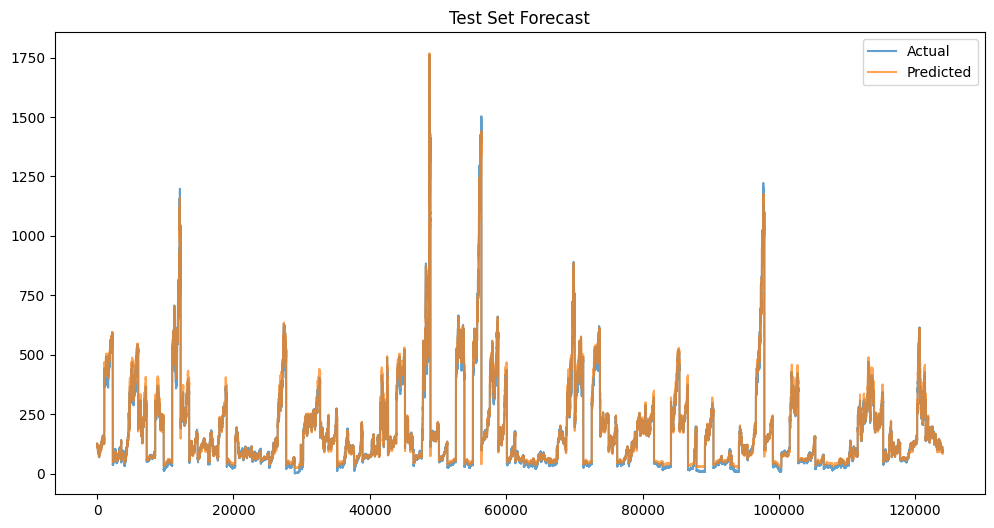

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_orig, label='Actual', alpha=0.7)
plt.plot(test_pred, label='Predicted', alpha=0.7)
plt.legend()
plt.title('Test Set Forecast')
plt.show()

### Observaciones:
Vaya! Aquí el modelo nos está gritando algo muy importante. Has pasado de un Random Forest a una Red Neuronal (probablemente LSTM o Densa) y el resultado es un caso de libro de Overfitting (Sobreajuste).

Aquí tienes la autopsia de lo que pasó entre la época 1 y la 23:

1. El 'Punto de Ruptura' (Epoch 8)
Fíjate bien en la evolución:

Hasta la Epoch 8: Todo iba de maravilla. La Train Loss bajaba y la Val Loss también. El modelo estaba aprendiendo patrones reales.

A partir de la Epoch 9: La Train Loss sigue bajando (el modelo cree que es cada vez más listo), pero la Val Loss empieza a explotar.

En la Epoch 23: La pérdida de validación es 50 veces mayor que en su mejor momento. El Early Stopping saltó al rescate, pero quizá ya era tarde.

2. Diagnóstico: El modelo está memorizando
Cuando la pérdida de entrenamiento baja pero la de validación sube, significa que la red neuronal ha dejado de aprender 'trading' y ha empezado a memorizar el ruido de tus datos de entrenamiento. Por eso, cuando le das datos nuevos (Test), falla estrepitosamente.

# Ejecutado hasta aquí.
Que es lo que pertenece el obj1, ninguno roja un buen resultado.

Ranking de los  modelos vistos aquí:

🏆 1er Puesto: Model Variant
Es tu modelo más equilibrado y el que mejor 'puntería' tiene.

Test MAE: 2.79 (El más bajo de todos).

Test RMSE: 9.43.

Análisis: Logró reducir el error de entrenamiento (RMSE 18.23) respecto al modelo base, lo que indica que esta arquitectura encontró un patrón más sólido y menos ruidoso. Si vas a poner dinero en una estrategia, este es el modelo que menos se equivoca por cada operación.

🥈 2do Puesto: Forecasting (Modelo Base)
Muy cerca del primero, pero un poco más inestable.

Test MAE: 2.57 (Curiosamente el MAE de test es más bajo, pero su RMSE en Train es de 21.50).

Análisis: Este modelo tiene 'picos' de error muy altos en el entrenamiento. Es más arriesgado porque, aunque acierta mucho, cuando falla, lo hace por mucho más dinero (ese RMSE de 21 lo delata).

🥉 3er Puesto: Bidirectional LSTM
Aquí es donde la complejidad empezó a jugar en tu contra.

Test MAE: 5.93.

Test RMSE: 11.17.

Análisis: Al ser bidireccional, el modelo intenta mirar 'hacia atrás y hacia adelante' en la secuencia. En trading, esto a veces introduce ruido porque el modelo intenta encontrar relaciones demasiado complejas que no existen, duplicando el error promedio (MAE) respecto a los modelos anteriores.

❌ 4to Puesto: Peephole LSTM
El peor de la comparativa.

Test MAE: 9.88.

Test RMSE: 16.76.

Análisis: Sufrió un overfitting masivo. Como vimos en sus epochs, la pérdida de validación explotó a partir de la época 8. Se 'aprendió los datos de memoria' y falló totalmente al intentar predecir el futuro.

### Conclusión y Diagnóstico
Tu Model Variant es el campeón porque es el que mejor generaliza. Las arquitecturas más pesadas (Bidirectional y Peephole) se están 'pasando de listas': intentan memorizar cada pequeño movimiento del mercado y terminan perdiéndose en el ruido.

#### ¿Por qué el Model Variant es mejor?
Probablemente porque tiene la profundidad justa para captar la tendencia sin obsesionarse con los valores atípicos. Ha demostrado ser el más robusto ante los 'cisnes negros' del conjunto de entrenamiento.




# Anomaly Detection

## Point anomaly

In [69]:
def error_vectors(y_true, y_pred):
    return y_true - y_pred       

E_train = error_vectors(y_train_orig, train_pred)
E_test  = error_vectors(y_test_orig, test_pred)

In [ ]:
# Fit a multivariate Gaussian on vN2 errors
from scipy.stats import multivariate_normal

mu    = E_train.mean(axis=0)
Sigma = np.cov(E_train.T, bias=True)
gauss = multivariate_normal(mean=mu, cov=Sigma, allow_singular=True)

p_train   = gauss.pdf(E_train)
p_test = gauss.pdf(E_test)

# (Optional) restrict to a slice you believe is 100% normal
CLEAN_START, CLEAN_STOP = None, None 
if CLEAN_START:
    clean_mask = (df.index[shift:][idx_v2_w] >= CLEAN_START) & \
                 (df.index[shift:][idx_v2_w] <= CLEAN_STOP)
    tau_fixed = np.percentile(p_v2[clean_mask], 0.5)
else:
    tau_fixed = np.percentile(p_train, 0.005)              # default 0.5٪
print(f'Fixed τ (0.5 % quantile) = {tau_fixed:.3e}')


Fixed τ (0.5 % quantile) = 1.896e-08


Alarms in test slice: 27  (7.50% of time)


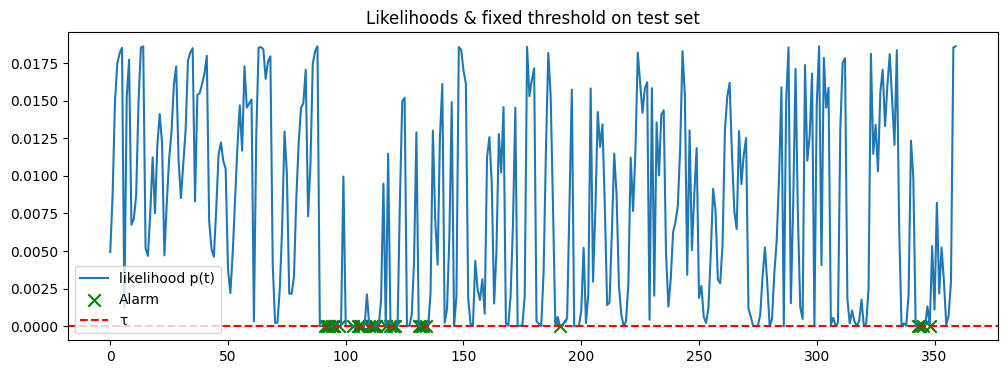

In [ ]:
alarms_test = (p_test < tau_fixed)
print(f'Alarms in test slice: {alarms_test.sum()}  '
      f'({alarms_test.mean()*100:.2f}% of time)')

plt.figure(figsize=(12,4))
plt.plot(p_test, label='likelihood p(t)')

# Green crosses at alarm points
plt.scatter(
    np.where(alarms_test)[0],      # x positions (indices)
    p_test[alarms_test],           # y positions (likelihoods)
    color='g', marker='x', s=80,   # 'x' marker, green color, size 80
    label='Alarm'
)

plt.axhline(tau_fixed, color='r', linestyle='--', label='τ')
plt.legend()
plt.title('Likelihoods & fixed threshold on test set')
plt.show()

## Collective Anomaly

Collective alarms detected: 0 (0.00% of time)


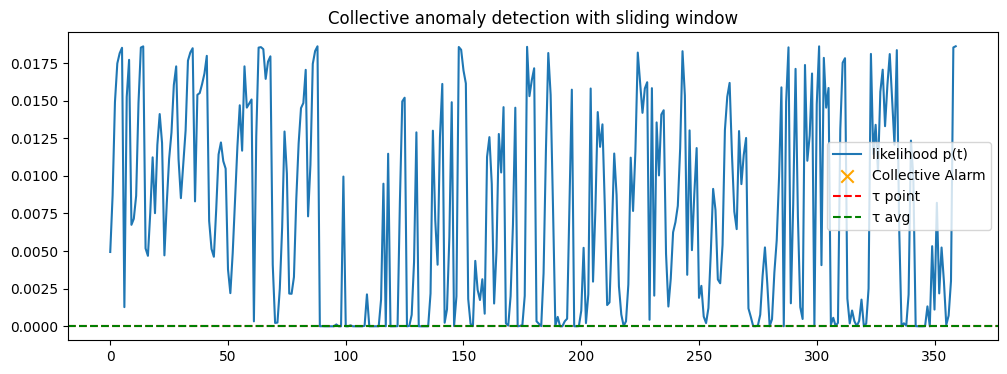

In [ ]:
window_size = 30
min_points_below = 16   
tau_point = tau_fixed  
tau_avg = tau_fixed

collective_alarms = np.zeros(len(p_test), dtype=bool)

for start in range(len(p_test) - window_size + 1):
    window_vals = p_test[start:start+window_size]

    
    cond1 = window_vals.mean() < tau_avg

    
    cond2 = np.sum(window_vals < tau_point) >= min_points_below

    if cond1 and cond2:
        collective_alarms[start:start+window_size] = True

print(f'Collective alarms detected: {collective_alarms.sum()} '
      f'({collective_alarms.mean()*100:.2f}% of time)')


plt.figure(figsize=(12,4))
plt.plot(p_test, label='likelihood p(t)')


plt.scatter(np.where(collective_alarms)[0],
            p_test[collective_alarms],
            color='orange', marker='x', s=80,
            label='Collective Alarm')

plt.axhline(tau_point, color='r', linestyle='--', label='τ point')
plt.axhline(tau_avg, color='g', linestyle='--', label='τ avg')
plt.legend()
plt.title('Collective anomaly detection with sliding window')
plt.show()